In [52]:
print("Step 1: Importing libraries")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

Step 1: Importing libraries


# Sales 



we are going to check import libraries 


In [36]:
# importing the dataset
df = pd.read_csv('../resources/Sales_Train.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [37]:
df.tail()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976
8522,DRG01,14.800,Low Fat,0.044878,Soft Drinks,75.4670,OUT046,1997,Small,Tier 1,Supermarket Type1,765.6700


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [39]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [40]:
df['Outlet_Type']

0       Supermarket Type1
1       Supermarket Type2
2       Supermarket Type1
3           Grocery Store
4       Supermarket Type1
              ...        
8518    Supermarket Type1
8519    Supermarket Type1
8520    Supermarket Type1
8521    Supermarket Type2
8522    Supermarket Type1
Name: Outlet_Type, Length: 8523, dtype: object

In [41]:
# checking th missing values
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

## filling the missing values
Item_Weight with mean 
and Item_Size with

In [42]:
# handling the missing values
mean_weight = df['Item_Weight'].mean()
df['Item_Weight'].fillna(mean_weight, inplace=True)

# verify the changes
df.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

### filling the Outlet_size 

now to fill Outlet size which is a categorical variable ... 
we will first check its relationship with other categorical variables

In [43]:
# Does Outlet_Size depend on Outlet_Type or Outlet_Location_Type?
print("Outlet_Size distribution within each Outlet_Type:")
print(pd.crosstab(df['Outlet_Type'], df['Outlet_Size'], normalize='index')*100)

print("\nOutlet_Size distribution within each Outlet_Location_Type:")
print(pd.crosstab(df['Outlet_Location_Type'], df['Outlet_Size'], normalize='index')*100)

Outlet_Size distribution within each Outlet_Type:
Outlet_Size             High      Medium       Small
Outlet_Type                                         
Grocery Store       0.000000    0.000000  100.000000
Supermarket Type1  25.040301   24.986566   49.973133
Supermarket Type2   0.000000  100.000000    0.000000
Supermarket Type3   0.000000  100.000000    0.000000

Outlet_Size distribution within each Outlet_Location_Type:
Outlet_Size                High     Medium       Small
Outlet_Location_Type                                  
Tier 1                 0.000000  38.944724   61.055276
Tier 2                 0.000000   0.000000  100.000000
Tier 3                33.345259  66.654741    0.000000


So there is a relationship between Outlet_Size and Outlet_Location_Type and Outlet_Type

In [44]:
# FILLING THE MISSING VALUES IN OUTLET_SIZE WE OUTLETTYPE AND LOCATIONS

df['Outlet_Size'].fillna(df.groupby(['Outlet_Type', 'Outlet_Location_Type'])['Outlet_Size'].transform(lambda x: x.fillna(x.mode()[0] if len(x.mode()) > 0 else 'medium')), inplace=True)
# If any missing values are still there, fill them with Outlet_Type alone


# verify the changes
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

#### good no null values left

In [45]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


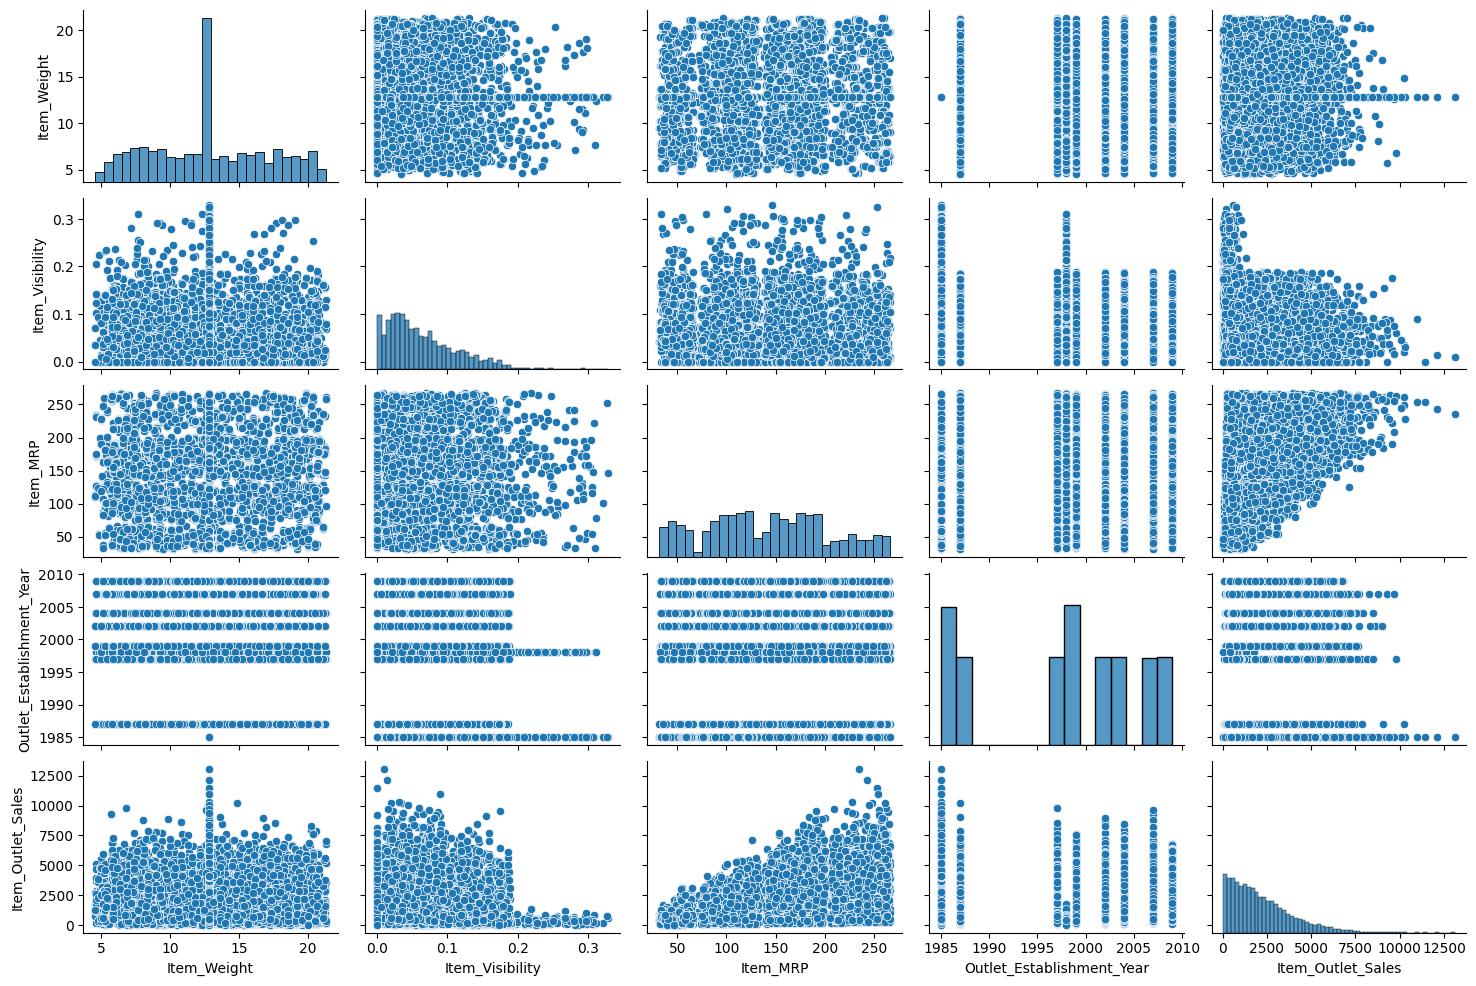

In [46]:
# Pairplot of all numeric columns with correct parameters
sns.pairplot(df, height=2, aspect=1.5)
plt.show()

Relationships:

No strong linear correlation between numeric variables
Item_MRP and Item_Weight appear independent
Item_Visibility is very sparse (most items have low shelf visibility)

In [32]:
# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix) 

                           Item_Weight  Item_Visibility  Item_MRP  \
Item_Weight                   1.000000        -0.016380  0.045257   
Item_Visibility              -0.016380         1.000000 -0.014013   
Item_MRP                      0.045257        -0.014013  1.000000   
Outlet_Establishment_Year     0.013548        -0.097040 -0.007233   

                           Outlet_Establishment_Year  
Item_Weight                                 0.013548  
Item_Visibility                            -0.097040  
Item_MRP                                   -0.007233  
Outlet_Establishment_Year                   1.000000  


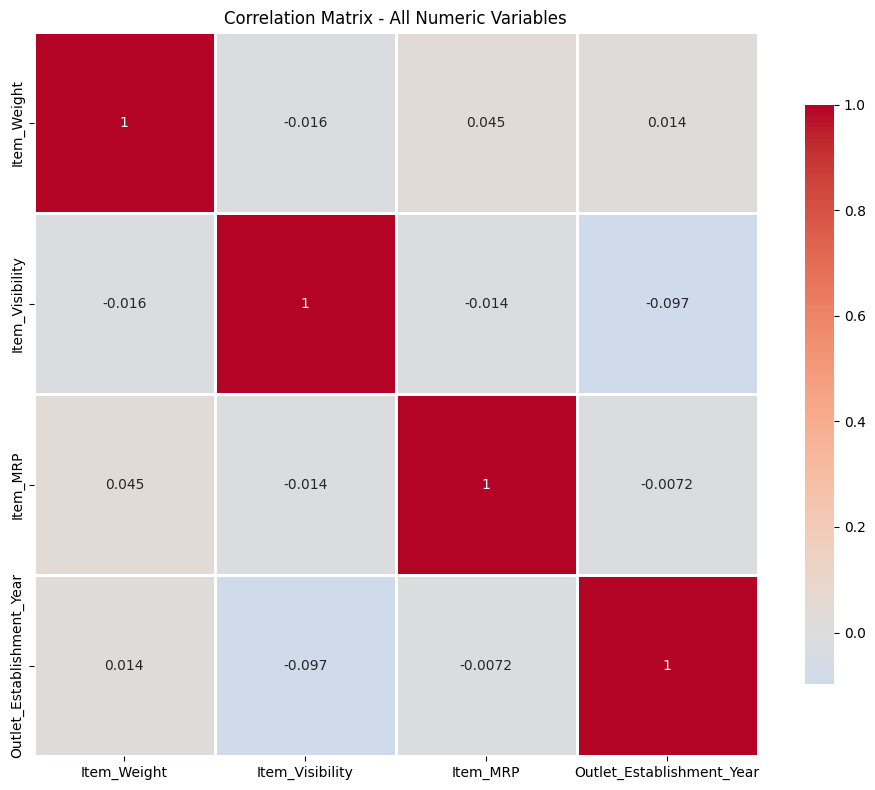

In [51]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Numeric Variables')
plt.tight_layout()
plt.show()

In [50]:
print("All columns:")
print(df.columns)
print(f"\nDataset shape: {df.shape}")
print(f"\nTarget variable stats:")
print(df['Item_Outlet_Sales'].describe())

All columns:
Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

Dataset shape: (8523, 12)

Target variable stats:
count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


### Excellent! Now you have everything:

Target Variable: Item_Outlet_Sales

Range: 33.29 to 13,086.96
Mean: 2,181.29
8,523 samples

# Next step: Build a Linear Regression Model
Here's the plan:

Encode categorical variables (Item_Fat_Content, Item_Type, Outlet_Size, Outlet_Location_Type, Outlet_Type)
Split data into train/test
Train model and make predictions
Evaluate performance with R² and RMSE
Analyze feature importance

### Encode categorical variables 
(Item_Fat_Content, Item_Type, Outlet_Size, Outlet_Location_Type, Outlet_Type)

In [53]:
categorical_cols = ['Item_Fat_Content', 'Item_Type',  'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print(df.head())

  Item_Identifier  Item_Weight  Item_Fat_Content  Item_Visibility  Item_Type  \
0           FDA15         9.30                 1         0.016047          4   
1           DRC01         5.92                 2         0.019278         14   
2           FDN15        17.50                 1         0.016760         10   
3           FDX07        19.20                 2         0.000000          6   
4           NCD19         8.93                 1         0.000000          9   

   Item_MRP Outlet_Identifier  Outlet_Establishment_Year  Outlet_Size  \
0  249.8092            OUT049                       1999            1   
1   48.2692            OUT018                       2009            1   
2  141.6180            OUT049                       1999            1   
3  182.0950            OUT010                       1998            3   
4   53.8614            OUT013                       1987            0   

   Outlet_Location_Type  Outlet_Type  Item_Outlet_Sales  
0                     

### Split data into train/test
Train model and make predictions

In [ ]:
X =df.drop(['Item_Identifier','Outlet_Identifier','Item_Outlet_Sales'], axis=1)
y = df['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Train model

lm = LinearRegression()
lm.fit(X_train, y_train)
# Predict on test set
y_pred = lm.predict(X_test)



In [59]:
# Calculate the residuals (errors)

print('mean_squared_error:', mean_squared_error(y_test, y_pred))
print('r2_score:', r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('rmse:', rmse)

mean_squared_error: 1380108.2386041905
r2_score: 0.5072790332706454
rmse: 1174.7800809531077


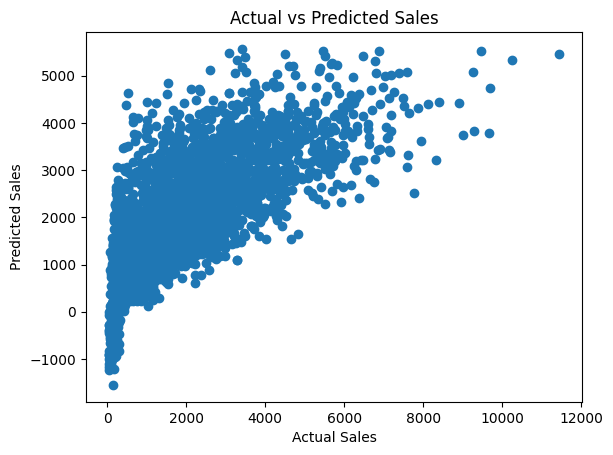

In [57]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.show()

# Final Model Performance:

Metric	Value
R² Score	0.507 (50.7%)
RMSE	1,174.78
Mean Sales	2,181.29
Error %	53.8%
Interpretation:

The model explains 51% of sales variance, with an average prediction error of $1,175. For a product with average sales of $2,181, the model is off by ~54% on average.

This is moderate performance - better than random guessing but with room for improvement.

## Why not perfect?

Weak correlations between features and sales
Non-linear relationships (linear regression can't capture them)
Missing important features

# Next Learning Steps:

##### Try better models (Random Forest, XGBoost) - they handle non-linear patterns
##### Use OneHotEncoder - properly encode categorical variables
##### Feature Engineering - create new features (e.g., price_per_weight)
##### Standardize/Normalize - scale numeric features for better performance